#### import Libraries

In [17]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.append(os.path.abspath('..'))

from src.model_advanced import (
    train_decision_tree,
    train_mlp_sklearn,
    train_pytorch_model,
    evaluate_advanced_model,
    save_advanced_model,
    save_pytorch_model
)

### Load Processed datasets

In [18]:
train = pd.read_csv('../data/processed/train_processed.csv')
val = pd.read_csv('../data/processed/val_processed.csv')
test = pd.read_csv('../data/processed/test_processed.csv')

### X and y split

In [19]:
X_train = train.drop('Survived', axis=1)
y_train = train['Survived']
X_val = val.drop('Survived', axis=1)
y_val = val['Survived']

# For test data, keep PassengerId for submission later
passenger_ids = test['PassengerId']
X_test = test.drop('PassengerId', axis=1)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"features {X_train.columns.tolist()}")

Train: (712, 20), Val: (179, 20)
features ['Pclass', 'Sex', 'Fare', 'AgeGroupOrdinal', 'IsAlone', 'Title_Col', 'Title_Countess', 'Title_Dr', 'Title_Lady', 'Title_Major', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rev', 'Embarked_Q', 'Embarked_S']


## Decision Tree

In [20]:
print("\n" + "="*60)
print("🌳 Decision Tree")
start = time.time()
dt_model = train_decision_tree(
    X_train, y_train,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)
end = time.time()
print(f"⏱️ training Time: {end - start:.4f} s")
dt_pred, dt_acc = evaluate_advanced_model(dt_model, X_val, y_val, model_type='sklearn')


🌳 Decision Tree
⏱️ training Time: 0.0000 s
Validation Accuracy: 0.8436

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.78      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179


Confusion Matrix:
 [[93 12]
 [16 58]]


## MLP

In [21]:
print("\n" + "="*60)
print("🧠 MLP (Scikit-Learn)")
start = time.time()
mlp_model = train_mlp_sklearn(
    X_train, y_train,
    hidden_layer_sizes=(128, 64, 32),
    alpha=0.001,
    learning_rate_init=0.001
)
end = time.time()
print(f"⏱️ training Time: {end - start:.4f} s")
mlp_pred, mlp_acc = evaluate_advanced_model(mlp_model, X_val, y_val, model_type='sklearn')


🧠 MLP (Scikit-Learn)
⏱️ training Time: 0.0610 s
Validation Accuracy: 0.7039

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.75       105
           1       0.65      0.61      0.63        74

    accuracy                           0.70       179
   macro avg       0.69      0.69      0.69       179
weighted avg       0.70      0.70      0.70       179


Confusion Matrix:
 [[81 24]
 [29 45]]


## Pytorch

In [22]:
print("\n" + "="*60)
print("🔥 PyTorch MLP")
start = time.time()
input_dim = X_train.shape[1]
pytorch_model, history = train_pytorch_model(
    X_train, y_train, X_val, y_val,
    input_dim=input_dim,
    epochs=100,
    batch_size=32,
    lr=0.001,
    hidden_dims=[128, 64, 32]
)
end = time.time()
print(f"⏱️ training Time: {end - start:.4f} s")
pt_pred, pt_acc = evaluate_advanced_model(pytorch_model, X_val, y_val, model_type='pytorch')


🔥 PyTorch MLP
Epoch 10/100 | Train Loss: 0.5335 | Val Loss: 0.4952 | Val Acc: 0.7654
Epoch 20/100 | Train Loss: 0.4823 | Val Loss: 0.4721 | Val Acc: 0.7709
Epoch 30/100 | Train Loss: 0.4630 | Val Loss: 0.4622 | Val Acc: 0.7765
Epoch 40/100 | Train Loss: 0.4552 | Val Loss: 0.4646 | Val Acc: 0.7821
Epoch 50/100 | Train Loss: 0.4342 | Val Loss: 0.4662 | Val Acc: 0.7877
Epoch 60/100 | Train Loss: 0.4274 | Val Loss: 0.4388 | Val Acc: 0.7877
Epoch 70/100 | Train Loss: 0.4257 | Val Loss: 0.4370 | Val Acc: 0.8156
Epoch 80/100 | Train Loss: 0.4063 | Val Loss: 0.4288 | Val Acc: 0.8212
Epoch 90/100 | Train Loss: 0.4046 | Val Loss: 0.4259 | Val Acc: 0.8101
Epoch 100/100 | Train Loss: 0.4069 | Val Loss: 0.4240 | Val Acc: 0.8212
⏱️ training Time: 3.1115 s
Validation Accuracy: 0.8212

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.73      0.77        74

    accuracy                  

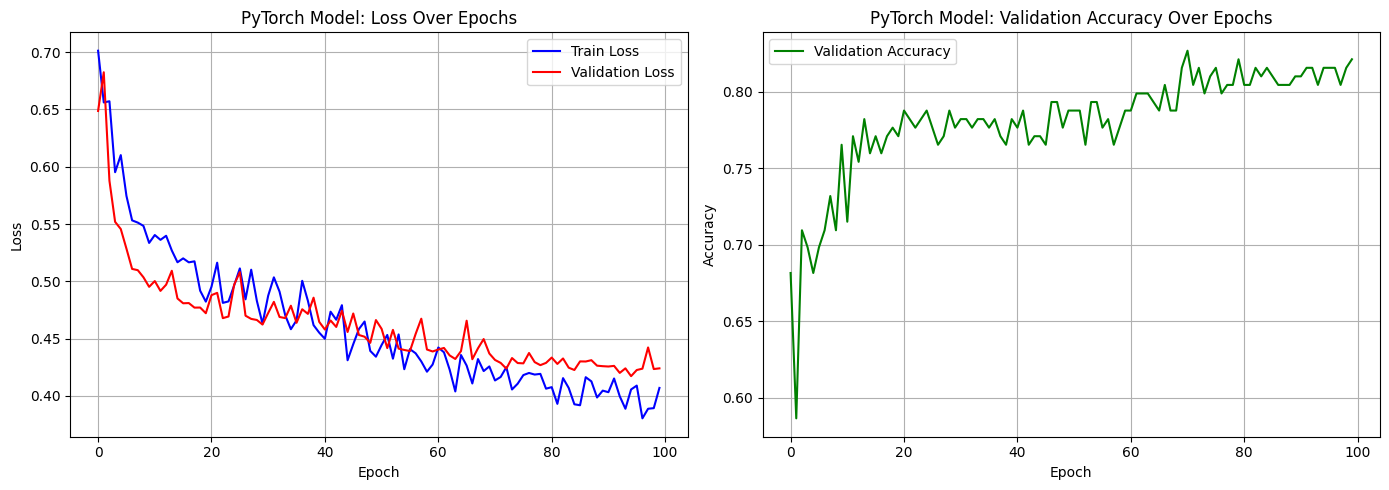

In [23]:
# ---------- Visualize PyTorch Training History ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Validation Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('PyTorch Model: Loss Over Epochs')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('PyTorch Model: Validation Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../reports/figures/pytorch_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Results


📊 Model Performance Comparison (Validation Set)
             Model  Validation Accuracy
     Decision Tree             0.843575
       PyTorch MLP             0.821229
MLP (Scikit-Learn)             0.703911


C:\Users\Digital City\AppData\Local\Temp\ipykernel_15384\2336313868.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Validation Accuracy', y='Model', data=results, palette='viridis')


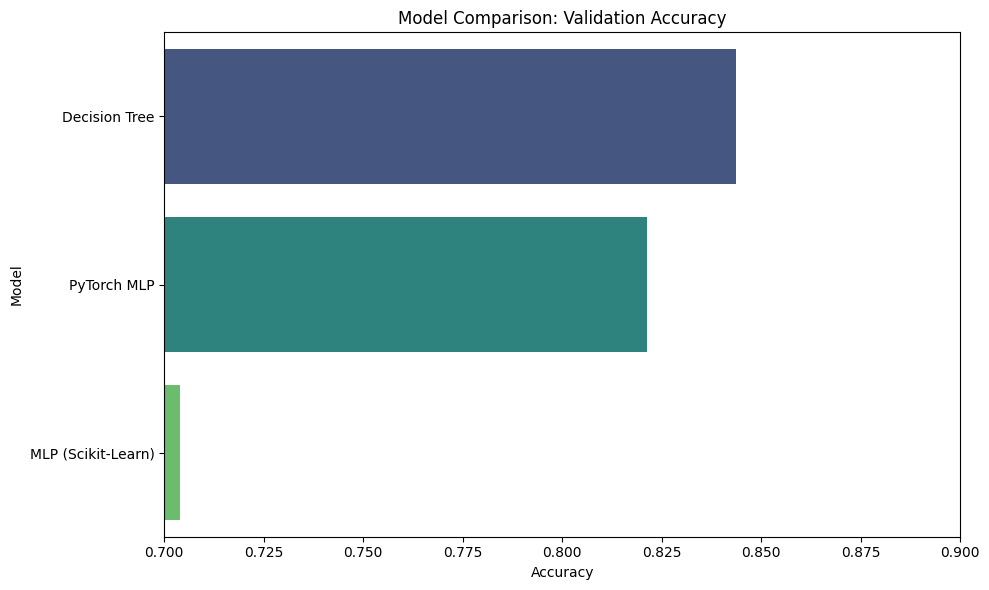

In [24]:
# ---------- Compare Results ----------
print("\n" + "="*60)
print("📊 Model Performance Comparison (Validation Set)")
print("="*60)

results = pd.DataFrame({
    'Model': ['Decision Tree', 'MLP (Scikit-Learn)', 'PyTorch MLP'],
    'Validation Accuracy': [dt_acc, mlp_acc, pt_acc]
})

# Sort by accuracy (best first)
results = results.sort_values('Validation Accuracy', ascending=False)

print(results.to_string(index=False))

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Validation Accuracy', y='Model', data=results, palette='viridis')
plt.xlabel('Accuracy')
plt.title('Model Comparison: Validation Accuracy')
plt.xlim(0.7, 0.9)  # Adjust as needed
plt.tight_layout()
plt.savefig('../reports/figures/advanced_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save the best model

In [25]:
# ---------- Save the Best Model ----------
best_idx = results['Validation Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_acc = results.loc[best_idx, 'Validation Accuracy']

print(f"\n🏆 Best Model: {best_model_name} with Validation Accuracy: {best_acc:.4f}")

# Determine which model object to save
if best_model_name == 'Decision Tree':
    save_advanced_model(dt_model, '../models/best_advanced_model.pkl')
    best_model = dt_model
    model_type = 'sklearn'
elif best_model_name == 'MLP (Scikit-Learn)':
    save_advanced_model(mlp_model, '../models/best_advanced_model.pkl')
    best_model = mlp_model
    model_type = 'sklearn'
else:  # PyTorch MLP
    save_pytorch_model(pytorch_model, '../models/best_pytorch_model.pth')
    best_model = pytorch_model
    model_type = 'pytorch'

print("\n✅ Best model saved successfully!")


🏆 Best Model: Decision Tree with Validation Accuracy: 0.8436
Model saved to ../models/best_advanced_model.pkl

✅ Best model saved successfully!


# Generate Submission File

In [26]:
# ---------- Generate Kaggle Submission ----------
print("\n" + "="*60)
print("📝 Generating Submission File")
print("="*60)

if model_type == 'sklearn':
    test_preds = best_model.predict(X_test)
else:  # PyTorch
    X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
    with torch.no_grad():
        outputs = best_model(X_test_t)
        test_preds = (outputs >= 0.5).float().numpy().flatten()

# Convert to integers (0/1)
test_preds = test_preds.astype(int)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': test_preds
})

# Save to CSV
submission.to_csv('../submissions/submission_advanced.csv', index=False)
print("✅ Submission file saved to: submissions/submission_advanced.csv")
print("\nFirst 5 rows of submission:")
print(submission.head())

# Show summary
print(f"\n📊 Predicted survival distribution in test set:")
print(f"Survived (1): {submission['Survived'].sum()} passengers")
print(f"Not Survived (0): {len(submission) - submission['Survived'].sum()} passengers")


📝 Generating Submission File
✅ Submission file saved to: submissions/submission_advanced.csv

First 5 rows of submission:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1

📊 Predicted survival distribution in test set:
Survived (1): 156 passengers
Not Survived (0): 262 passengers
